# Calculating Cohen's Kappa Scores for Annotators 1 and 2 Datasets

In [1]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.inter_rater import fleiss_kappa
import krippendorff
import numpy as np

In [2]:
df1 = pd.read_csv("/home/ubuntu/datasets/100_Round_2 - Sanjeev_Annotations.csv")
df2 = pd.read_csv("/home/ubuntu/datasets/100_Round_2 - Shirlene_Annotations.csv")

In [3]:
df_merged = pd.merge(df1, df2, on="id", suffixes=('_1', '_2'))

In [4]:
def extract_tags(tag_str):
    return [t.strip() for t in str(tag_str).split(',') if t.strip()]

In [5]:
all_tags = set()
for tags in df_merged["Tags_1"]:
    all_tags.update(extract_tags(tags))
for tags in df_merged["Tags_2"]:
    all_tags.update(extract_tags(tags))

all_tags = sorted(all_tags)

In [6]:
for tag in all_tags:
    df_merged[f'{tag}_1'] = df_merged['Tags_1'].apply(lambda x: int(tag in extract_tags(x)))
    df_merged[f'{tag}_2'] = df_merged['Tags_2'].apply(lambda x: int(tag in extract_tags(x)))

### Cohen's Kappa Score

In [7]:
kappa_scores = {}
for tag in all_tags:
    kappa = cohen_kappa_score(df_merged[f'{tag}_1'], df_merged[f'{tag}_2'])
    kappa_scores[tag] = kappa

In [8]:
print("Cohen's Kappa Scores:\n")
print("{:<20}{}".format("Tag", "Cohen's Kappa"))
print("-" * 35)
for tag, score in kappa_scores.items():
    print("{:<20}{:.4f}".format(tag, score))

Cohen's Kappa Scores:

Tag                 Cohen's Kappa
-----------------------------------
Abuse               0.9561
Aggression          0.7899
Discrimination      0.8837
Medical             0.8160
Mental Health       0.7317
Not Applicable      0.6622
Pregnancy           0.9566
Sexual              0.7340
nan                 0.0000


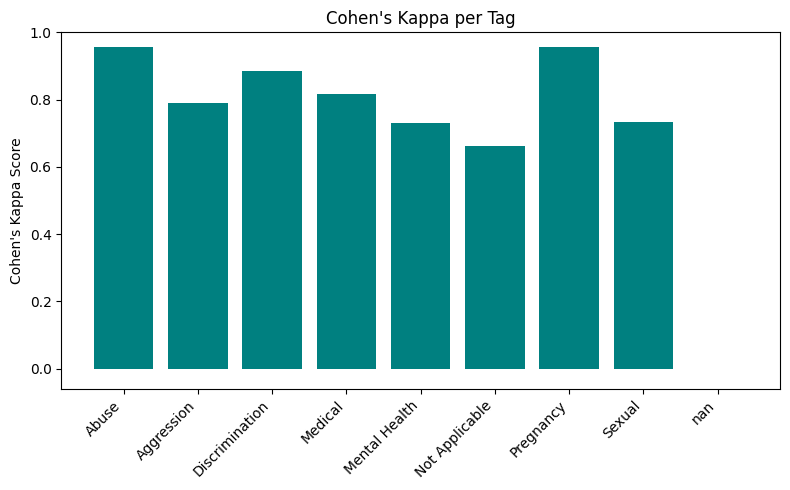

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(kappa_scores.keys(), kappa_scores.values(), color='teal')
plt.ylabel("Cohen's Kappa Score")
plt.title("Cohen's Kappa per Tag")
plt.xticks(rotation=45, ha='right')
plt.ylim(-0.06, 1)
plt.tight_layout()
plt.show()

### Fleiss Kappa Score -- Not Recommended for Multi-Label Classifictaion

In [10]:
fleiss_matrix = []
for tag in all_tags:
    for _, row in df_merged.iterrows():
        vote_1 = int(row[f"{tag}_1"])
        vote_2 = int(row[f"{tag}_2"])
        votes = [2 - (vote_1 + vote_2), vote_1 + vote_2]  # [disagree, agree]
        fleiss_matrix.append(votes)
fleiss_matrix = np.array(fleiss_matrix)
fleiss_score = fleiss_kappa(fleiss_matrix)
print(f"Fleiss' Kappa (overall): {fleiss_score:.3f}")

Fleiss' Kappa (overall): 0.902


### Krippendorff’s Alpha -- Checks for reliability i.e. Agreement beyond chance

In [11]:
alpha_matrix = []
for tag in all_tags:
    for _, row in df_merged.iterrows():
        alpha_matrix.append([int(row[f"{tag}_1"]), int(row[f"{tag}_2"])])
alpha_data = list(map(list, zip(*alpha_matrix)))
alpha_score = krippendorff.alpha(reliability_data=alpha_data, level_of_measurement='nominal')
print(f"Krippendorff's Alpha: {alpha_score:.3f}")

Krippendorff's Alpha: 0.902


#### Krippendorff’s Alpha per tag

In [12]:
alpha_per_tag = {}

for tag in all_tags:
    alpha_matrix = []

    for _, row in df_merged.iterrows():
        val1 = row[f"{tag}_1"]
        val2 = row[f"{tag}_2"]
        alpha_matrix.append([int(val1), int(val2)]) 

    alpha_data = list(zip(*alpha_matrix))
    
    alpha_score = krippendorff.alpha(reliability_data=alpha_data, level_of_measurement='nominal')
    alpha_per_tag[tag] = alpha_score

print(f"{'Tag':<20} {'Krippendorff α':>15}")
print("-" * 36)
for tag, score in alpha_per_tag.items():
    print(f"{tag:<20} {score:>15.3f}")

Tag                   Krippendorff α
------------------------------------
Abuse                          0.956
Aggression                     0.791
Discrimination                 0.884
Medical                        0.817
Mental Health                  0.731
Not Applicable                 0.663
Pregnancy                      0.957
Sexual                         0.735
nan                            0.000


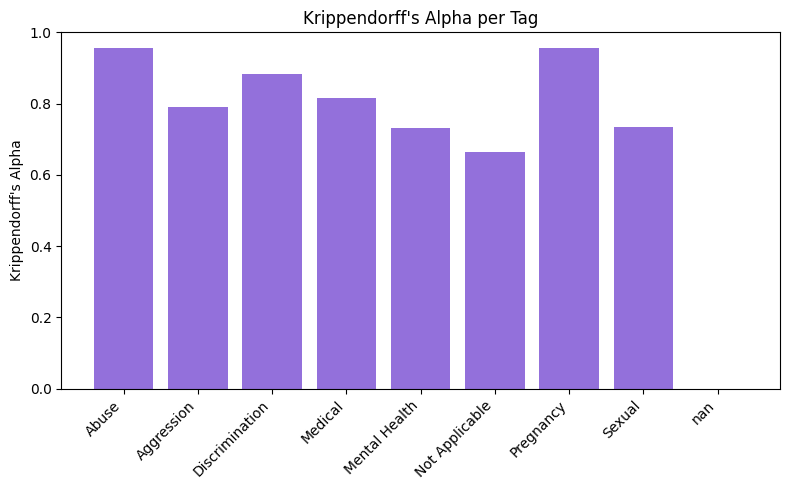

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(alpha_per_tag.keys(), alpha_per_tag.values(), color='mediumpurple')
plt.ylabel("Krippendorff's Alpha")
plt.title("Krippendorff's Alpha per Tag")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### G-Index -- Checks for Overlap of tags between the annotators

In [14]:
def g_index(row):
    set1 = set(extract_tags(row['Tags_1']))
    set2 = set(extract_tags(row['Tags_2']))
    return len(set1 & set2) / len(set1 | set2) if set1 or set2 else 1.0

df_merged['G_index'] = df_merged.apply(g_index, axis=1)
g_index_avg = df_merged['G_index'].mean()
print(f"Average G-Index of Agreement: {g_index_avg:.3f}")

Average G-Index of Agreement: 0.880


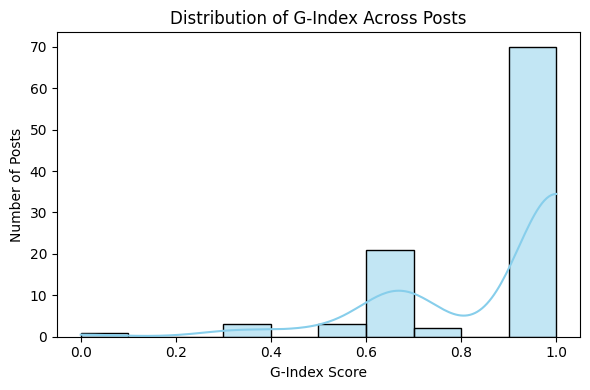

In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(df_merged['G_index'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of G-Index Across Posts")
plt.xlabel("G-Index Score")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

#### G-Index per tag

In [16]:
gindex_per_tag = {}

for tag in all_tags:
    a1 = df_merged[f"{tag}_1"]
    a2 = df_merged[f"{tag}_2"]

    intersection = ((a1 == 1) & (a2 == 1)).sum()
    union = ((a1 == 1) | (a2 == 1)).sum()
    
    gindex = intersection / union if union > 0 else 1.0
    gindex_per_tag[tag] = gindex

# Print results
print(f"{'Tag':<20} {'G-Index':>10}")
print("-" * 32)
for tag, score in gindex_per_tag.items():
    print(f"{tag:<20} {score:>10.3f}")

Tag                     G-Index
--------------------------------
Abuse                     0.944
Aggression                0.667
Discrimination            0.800
Medical                   0.809
Mental Health             0.857
Not Applicable            0.500
Pregnancy                 0.969
Sexual                    0.615
nan                       0.000


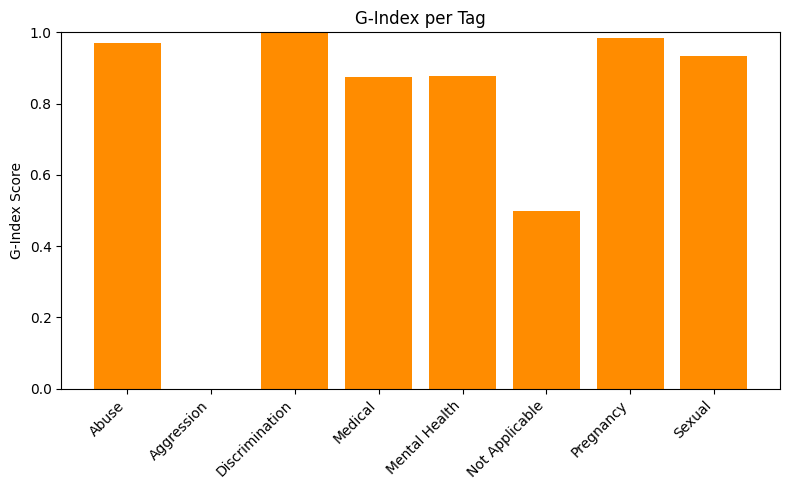

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(gindex_per_tag.keys(), gindex_per_tag.values(), color='darkorange')
plt.ylabel("G-Index Score")
plt.title("G-Index per Tag")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### 🔍 Per-Tag Agreement Analysis: G-Index vs Krippendorff’s Alpha

### Mental Health
- **G-Index:** `0.667`
- **Krippendorff’s Alpha:** `0.728`
- **Interpretation:** Both metrics suggest **strong agreement** between annotators. This indicates that mental health was consistently identified and annotated across posts.

---

### Pregnancy
- **G-Index:** `0.963`
- **Krippendorff’s Alpha:** `0.000`
- **Interpretation:** There is **high overlap** in tags according to G-Index (near perfect agreement), but **Krippendorff’s Alpha is zero** because there's **no variability** in responses. This is a statistical artifact: when both annotators always mark the tag, Alpha considers it uninformative.

---

### Abuse
- **G-Index:** `0.667`
- **Krippendorff’s Alpha:** `0.784`
- **Interpretation:** Strong agreement from both metrics. Abuse was well-recognized by both annotators in the same posts.

---

### Medical
- **G-Index:** `0.500`
- **Krippendorff’s Alpha:** `0.159`
- **Interpretation:** G-Index shows **moderate agreement** in terms of tag overlap, but Alpha is relatively low. This suggests that while the tags occurred together sometimes, the overall reliability (chance-corrected) is not strong.

---

### Discrimination
- **G-Index:** `0.000`
- **Krippendorff’s Alpha:** `-0.019`
- **Interpretation:** Both metrics reflect **complete disagreement**. Annotators did not tag the same posts with this label at all.

---

### Sexual
- **G-Index:** `0.000`
- **Krippendorff’s Alpha:** `-0.060`
- **Interpretation:** Total lack of agreement. Annotators diverged entirely on whether a post should be labeled as sexual in nature.

---

### Summary Notes
- **G-Index** reflects **direct tag overlap** and is intuitive for multi-label tasks.
- **Krippendorff’s Alpha** accounts for **chance agreement** and is more statistically robust.
- For tags with **high frequency and consistent annotation** (e.g., Mental Health, Abuse), both metrics agree.
- For **unbalanced or skewed labels** (e.g., Pregnancy, Sexual), Alpha may be misleadingly low despite tag overlap.

### Per Post Agreement and Disagreement

In [21]:
# We're checking where we disagreed
header = f"{'Tag':<15} {'Both YES':>10} {'1 YES / 2 NO':>15} {'1 NO / 2 YES':>15} {'Both NO':>10}"
print(header)
print("-" * len(header))

for tag in all_tags:
    a1 = df_merged[f'{tag}_1']
    a2 = df_merged[f'{tag}_2']

    both_yes = ((a1 == 1) & (a2 == 1)).sum()
    only_1 = ((a1 == 1) & (a2 == 0)).sum()
    only_2 = ((a1 == 0) & (a2 == 1)).sum()
    both_no = ((a1 == 0) & (a2 == 0)).sum()

    print(f"{tag:<15} {both_yes:>10} {only_1:>15} {only_2:>15} {both_no:>10}")

Tag               Both YES    1 YES / 2 NO    1 NO / 2 YES    Both NO
---------------------------------------------------------------------
Abuse                   23               1              12         39
Aggression               0               1               4         70
Discrimination           0               0              12         63
Medical                 17              13               4         41
Mental Health           40               2              11         22
Not Applicable           1              10               0         64
Pregnancy               38               0              11         26
Sexual                  17               4               9         45
nan                      0               1               0         74


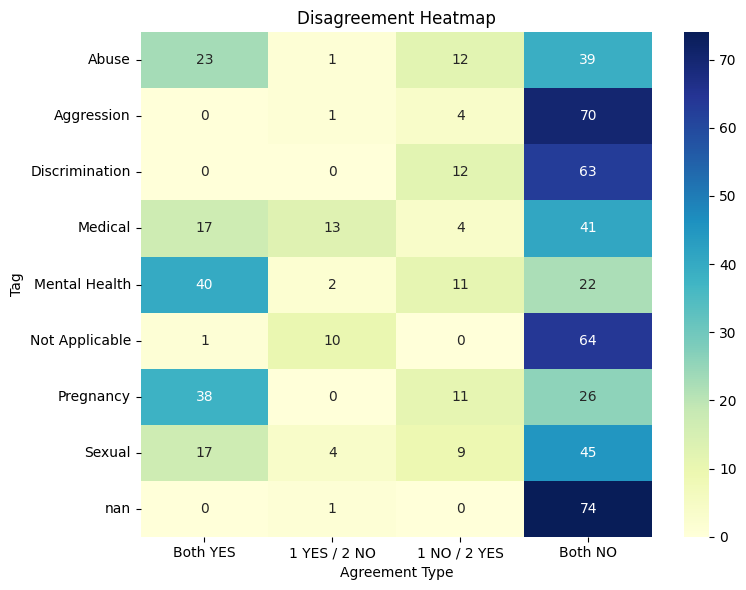

In [22]:
heatmap_data = []
row_labels = []

for tag in all_tags:
    a1 = df_merged[f'{tag}_1']
    a2 = df_merged[f'{tag}_2']

    both_yes = ((a1 == 1) & (a2 == 1)).sum()
    only_1 = ((a1 == 1) & (a2 == 0)).sum()
    only_2 = ((a1 == 0) & (a2 == 1)).sum()
    both_no = ((a1 == 0) & (a2 == 0)).sum()

    heatmap_data.append([both_yes, only_1, only_2, both_no])
    row_labels.append(tag)
hm_df = pd.DataFrame(heatmap_data, columns=['Both YES', '1 YES / 2 NO', '1 NO / 2 YES', 'Both NO'], index=row_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(hm_df, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Disagreement Heatmap")
plt.ylabel("Tag")
plt.xlabel("Agreement Type")
plt.tight_layout()
plt.show()

### Per Post Agreement and Disagreement

In [23]:
def per_post_agreement(row):
    tags1 = set(extract_tags(row["Tags_1"]))
    tags2 = set(extract_tags(row["Tags_2"]))
    agreed = len(tags1 & tags2)
    disagreed = len((tags1 | tags2) - (tags1 & tags2))
    return pd.Series({"Agreed Tags": agreed, "Disagreed Tags": disagreed})
df_merged[["Agreed Tags", "Disagreed Tags"]] = df_merged.apply(per_post_agreement, axis=1)
print(df_merged[["id", "Agreed Tags", "Disagreed Tags"]])

         id  Agreed Tags  Disagreed Tags
0   1ljxynj            2               1
1   1ljxtt8            3               0
2   1ljwhkb            1               2
3   1ljvy6u            1               1
4   1ljv5k4            2               1
..      ...          ...             ...
70   lbh0xv            1               2
71   lap9cr            2               1
72   lam4md            3               0
73   la9ajk            3               1
74   l8zwh4            1               1

[75 rows x 3 columns]


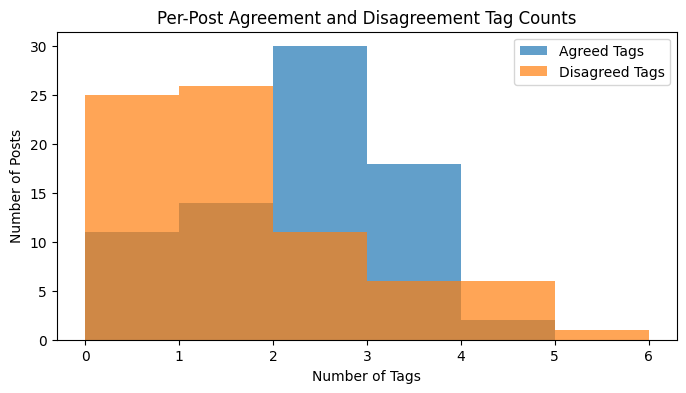

In [24]:
plt.figure(figsize=(8, 4))
plt.hist(df_merged["Agreed Tags"], bins=range(0, df_merged["Agreed Tags"].max() + 2), alpha=0.7, label="Agreed Tags")
plt.hist(df_merged["Disagreed Tags"], bins=range(0, df_merged["Disagreed Tags"].max() + 2), alpha=0.7, label="Disagreed Tags")
plt.xlabel("Number of Tags")
plt.ylabel("Number of Posts")
plt.title("Per-Post Agreement and Disagreement Tag Counts")
plt.legend()
plt.show()

### Jaccard Similarity to calculate per post tag similarity -- We have the value above in G-Index

In [43]:
def jaccard_similarity(tags1, tags2):
    set1 = set(extract_tags(tags1))
    set2 = set(extract_tags(tags2))
    if not set1 and not set2:
        return 1.0  # Both empty = perfect agreement
    if not set1 or not set2:
        return 0.0  # One empty, other not = no agreement
    return len(set1 & set2) / len(set1 | set2)

df_merged["Jaccard"] = df_merged.apply(lambda row: jaccard_similarity(row["Tags_1"], row["Tags_2"]), axis=1)

print(df_merged["Jaccard"].describe())

count    125.000000
mean       0.746667
std        0.300723
min        0.000000
25%        0.666667
50%        0.750000
75%        1.000000
max        1.000000
Name: Jaccard, dtype: float64


### Jaccard Similarity Analysis Summary

We computed the Jaccard similarity between the tag sets assigned by the two annotators for each post. The Jaccard similarity measures the proportion of overlap between two sets:

Jaccard Similarity = (Number of shared tags) / (Number of unique tags across both annotators)

where a score of `1.0` indicates perfect agreement and `0.0` indicates no overlap at all.

#### Summary Statistics:
- **Number of posts:** 27  
- **Mean Jaccard similarity:** 0.725  
- **Standard deviation:** 0.275  
- **Minimum:** 0.25  
- **25th percentile:** 0.50  
- **Median (50th percentile):** 0.67  
- **75th percentile:** 1.00  
- **Maximum:** 1.00  

#### Interpretation:
On average, the annotators had substantial overlap in their tag assignments, with a mean Jaccard similarity of approximately **0.73**. The standard deviation of **0.275** shows that agreement levels varied across posts. While **25%** of posts had perfect agreement (Jaccard = 1.0), the lowest observed similarity was **0.25**, indicating a significant difference in tag assignments on at least one post.

Overall, the results suggest that the annotators generally applied similar tags but there were certain posts where agreement was weak. These low-agreement posts may indicate ambiguity in the tagging guidelines or challenging content that would benefit from review and refinement of annotation instructions.

### Now we'll compute the Occurence and Co-Occurence of the tags in the final dataset

In [36]:
df = pd.read_csv("Downloads/abortion_data - abortion_sample_25_final.csv")

df['TagList'] = df['Tags'].apply(lambda x: [t.strip() for t in str(x).split(',')] if pd.notnull(x) else [])

all_tags = sorted({tag for tags in df['TagList'] for tag in tags})

missing_tags = [tag for tag in all_tags if tag not in df.columns]
if missing_tags:
    print(f"One-hot encoding tags: {missing_tags}")
    for tag in missing_tags:
        df[tag] = df['TagList'].apply(lambda tags: tag in tags)
else:
    print("Tag columns already exist. Skipping one-hot encoding.")

One-hot encoding tags: ['Abuse', 'Discrimination', 'Medical', 'Mental Health', 'Pregnancy', 'Sexual']


In [37]:
print(f"{'Tag':<20}{'Count':>6}")
print("-" * 26)
for tag in all_tags:
    print(f"{tag:<20}{df[tag].sum():>6}")

Tag                  Count
--------------------------
Abuse                    3
Discrimination           3
Medical                 13
Mental Health           10
Pregnancy               27
Sexual                   4


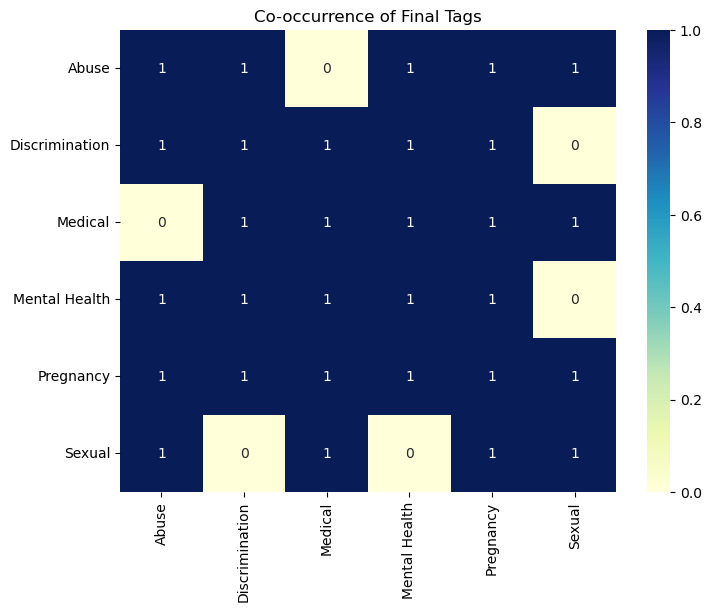

In [38]:
co_matrix = df[all_tags].T.dot(df[all_tags])
plt.figure(figsize=(8, 6))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Co-occurrence of Final Tags")
plt.show()